In [6]:
import xarray as xr
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cftime
import matplotlib
from tqdm import tqdm
#import xgcm
from xgcm import Grid

Converts CESM outputs on pressure levels, onto geopotential height levels (Z3), using the xgcm vertical regridding function. 

Code from here: https://xgcm.readthedocs.io/en/latest/transform.html#Realistic-Data-Example

In [29]:
def process_CE(ds):
    #ds = ds.sel(time=slice('2050', '2069')).groupby('time.month').mean(dim='time')
    ds = ds.mean('lon')
    ds = ds.rename({'lat':'latitude'})
    return ds

ds_HILLS_13_CE = process_CE(xr.open_dataset('/gws/nopw/j04/cpom/aduffey/pp_archive_hills/CESM_data/SO4_burden/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.so4_a1a2a3c1c2c3_zm.203501-206912.nc'))
ds_HILLS_15_CE = process_CE(xr.open_dataset('/gws/nopw/j04/cpom/aduffey/pp_archive_hills/CESM_data/SO4_burden/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.so4_a1a2a3c1c2c3_zm.203501-206912.nc'))

ds_Z_CE_13 = process_CE(xr.open_dataset('/gws/nopw/j04/cpom/aduffey/pp_archive_hills/CESM_data/Z3/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.Z3_zm.203501-206912.nc'))
ds_Z_CE_15 = process_CE(xr.open_dataset('/gws/nopw/j04/cpom/aduffey/pp_archive_hills/CESM_data/Z3/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.Z3_zm.203501-206912.nc'))


ds_HILLS_13_CE = xr.merge([ds_HILLS_13_CE, ds_Z_CE_13])
ds_HILLS_15_CE = xr.merge([ds_HILLS_15_CE, ds_Z_CE_15])

target_Z_levels = np.linspace(0, 30000, 100) # only need up to e.g. 30km

In [30]:
os.makedirs('/gws/nopw/j04/cpom/aduffey/pp_archive_hills/CESM_data/SO4_burdenZ/', exist_ok=True)

In [31]:
grid = Grid(ds_HILLS_13_CE, coords={'Z3': {'center': 'lev'},
                        },
                periodic=False
            )
ds_HILLS_13_CE_on_Z = grid.transform(ds_HILLS_13_CE.so4_a1a2a3c1c2c3, 'Z3', target_Z_levels, target_data=ds_HILLS_13_CE.Z3, method='linear')
ds_HILLS_13_CE_on_Z.to_netcdf('/gws/nopw/j04/cpom/aduffey/pp_archive_hills/CESM_data/SO4_burdenZ/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.so4_a1a2a3c1c2c3_zm_Z3.203501-206912.nc')

/home/users/a_duffey/.conda/envs/cmipv2/lib/python3.12/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


In [32]:
grid = Grid(ds_HILLS_15_CE, coords={'Z3': {'center': 'lev'},
                        },
                periodic=False
            )
ds_HILLS_15_CE_on_Z = grid.transform(ds_HILLS_15_CE.so4_a1a2a3c1c2c3, 'Z3', target_Z_levels, target_data=ds_HILLS_15_CE.Z3, method='linear')
ds_HILLS_15_CE_on_Z.to_netcdf('/gws/nopw/j04/cpom/aduffey/pp_archive_hills/CESM_data/SO4_burdenZ/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.so4_a1a2a3c1c2c3_zm_Z3.203501-206912.nc')

/home/users/a_duffey/.conda/envs/cmipv2/lib/python3.12/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


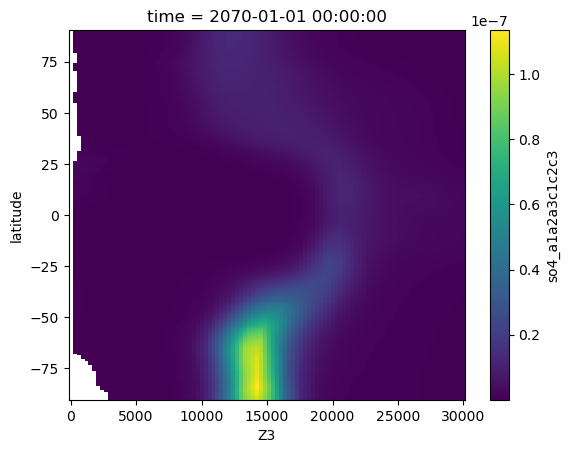

In [27]:
## plot to check

ds_HILLS_15_CE_on_Z.isel(time=-1).plot()

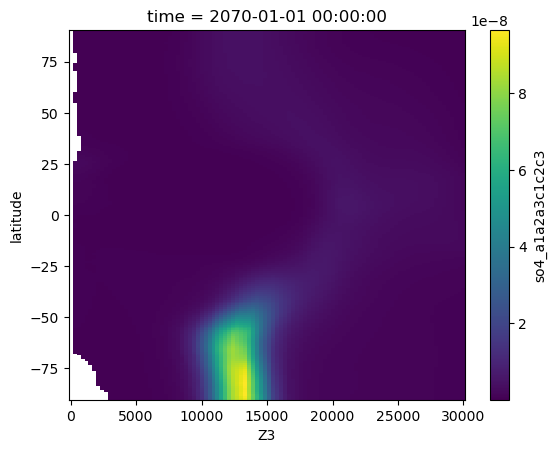

In [28]:
ds_HILLS_13_CE_on_Z.isel(time=-1).plot()

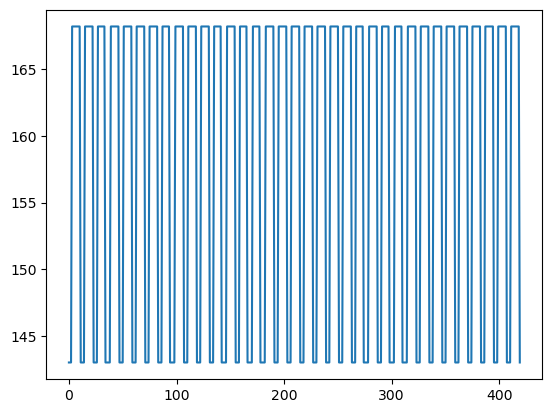

In [42]:
## DEV:
## also want to find the approx. vertical height of the CESM injection locations:
vals_13km = []
for t in ds_HILLS_13_CE.time.values:
    test = ds_HILLS_13_CE.sel(latitude=60, method='nearest').sel(time=t)  
    abs_diff_data = np.abs(test.Z3 - 13000)
    closest_indices_dict = abs_diff_data.argmin(...)
    vals_13km.append(test.isel(closest_indices_dict).Z3.item())

plt.plot(vals_13km)